# Sanity Checks

## Check continuity of the proposed two-body wavefunction

f2(L/2) = 0.9999999999999999
f2 continuity: short = 0.09749367563372811 long = 0.09749367563372811


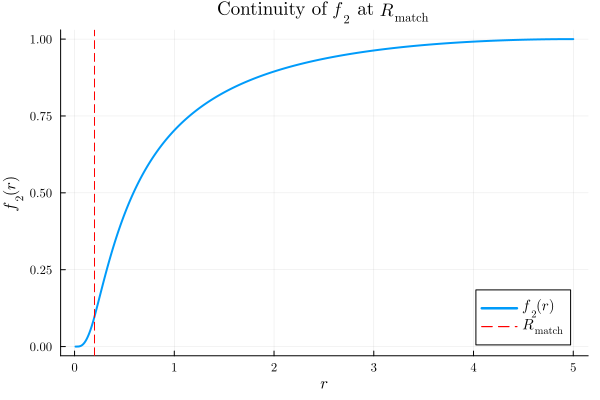

In [86]:
include("VMC_code.jl")
using Bessels

r = LinRange(0.01, 5.0, 500)  # Radial distances for g(r) calculation
R_match = 0.20 # Matching radius to validate continuity of f2
L = 10.0

# Test the continuity of f2 at the matching radius R_match

# First calculate the constants
constants = calculate_constants(L, R_match)
C1, C2, C3 = constants

f2 = Vector{Float64}(undef, length(r))
for i in 1:length(r)
    f2[i] = exp(u2(r[i], R_match, L, constants))
end

println("f2(L/2) = ", C2 * exp(-C3/(L/2)) * exp(-C3/(L/2)))
println("f2 continuity: short = ", C1*besselk(0, 2/sqrt(R_match)), 
        " long = ", C2*exp(-C3/R_match)*exp(-C3/(L-R_match)))


using LaTeXStrings
using Plots
gr()
default(fontfamily="Computer Modern", titlefont=12, legendfont=10)

plot(r, f2, 
     label=L"f_2(r)", 
     xlabel=L"r", 
     ylabel=L"f_2(r)", 
     title=L"Continuity of $f_2$ at $R_{\mathrm{match}}$",
     linewidth=2)
vline!([R_match], 
       label=L"R_{\mathrm{match}}", 
       linestyle=:dash, 
       color=:red)



## Continuity of the first derivative of the two-body wavefunction

df2/dr continuity: short = 1.20621882704054, long = 1.20621882704054
difference = 0.0


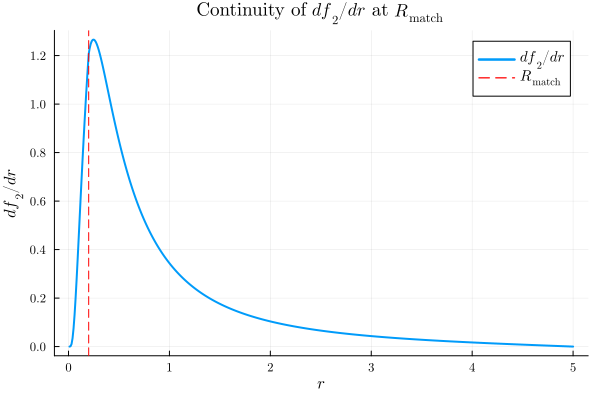

In [85]:
include("VMC_code.jl")
using Bessels

r = LinRange(0.01, 5.0, 500)  # Radial distances for g(r) calculation
R_match = 0.2 # Matching radius to validate continuity of f2
L = 10.0

# Test the continuity of f2 at the matching radius R_match

# First calculate the constants
constants = calculate_constants(L, R_match)
C1, C2, C3 = constants


f2 = Vector{Float64}(undef, length(r))
df2_dr = Vector{Float64}(undef, length(r))

for i in 1:length(r)
    f2[i] = exp(u2(r[i], R_match, L, constants))
    df2_dr[i] = f2[i] * u2_first_derivative(r[i], R_match, L, constants)
end

df2_short = exp(u2(R_match, R_match, L, constants)) * u2_first_derivative(R_match, R_match, L, constants)
df2_long  = exp(u2(R_match, R_match, L, constants))* u2_first_derivative(R_match, R_match, L, constants)
println("df2/dr continuity: short = $df2_short, long = $df2_long")
println("difference = $(abs(df2_short - df2_long))")

using LaTeXStrings
using Plots
gr()
default(fontfamily="Computer Modern", titlefont=12, legendfont=10)

plot(r, df2_dr, 
     label=L"$d f_2/dr$", 
     xlabel=L"r", 
     ylabel=L"$d f_2/dr$", 
     title=L"Continuity of $df_2/dr$ at $R_{\mathrm{match}}$",
     linewidth=2)
     
vline!([R_match], 
       label=L"R_{\mathrm{match}}", 
       linestyle=:dash, 
       color=:red)




## Validation of analytical derivatives of $u_2$

### First derivative

Analytical: $\frac{df_2}{dr} = u'_2(r) f_2(r)$ vs. Numerical: $\frac{df_2}{dr} = \frac{f_2(r + h) - f_2 (r-h)}{2h}$

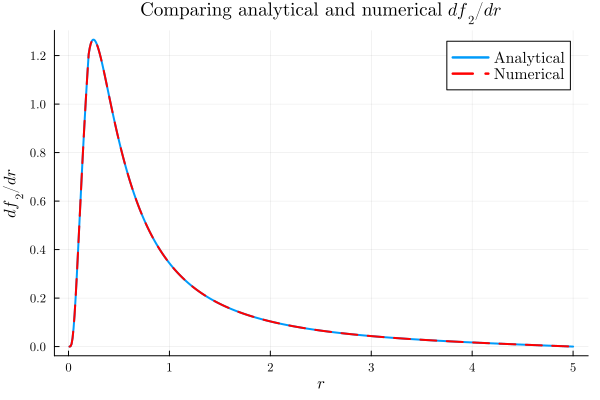

In [103]:
include("VMC_code.jl")
using Bessels

r = LinRange(0.01, 5.0, 500)  # Radial distances for g(r) calculation
R_match = 0.2 # Matching radius to validate continuity of f2
L = 10.0

# Test the continuity of f2 at the matching radius R_match

# First calculate the constants
constants = calculate_constants(L, R_match)
C1, C2, C3 = constants


f2 = Vector{Float64}(undef, length(r))
df2_dr = Vector{Float64}(undef, length(r))
df2_dr_num = Vector{Float64}(undef, length(r))

for i in 1:length(r)
    f2[i] = exp(u2(r[i], R_match, L, constants))
    df2_dr[i] = f2[i] * u2_first_derivative(r[i], R_match, L, constants)
    f2_plus = exp(u2(r[i] + 1e-5, R_match, L, constants))   
    f2_minus = exp(u2(r[i] - 1e-5, R_match, L, constants))
    df2_dr_num[i] = (f2_plus - f2_minus) / (2 * 1e-5)
end


using LaTeXStrings
using Plots
gr()
default(fontfamily="Computer Modern", titlefont=12, legendfont=10)

plot(r, df2_dr, 
     label="Analytical", 
     xlabel=L"r", 
     ylabel=L"$d f_2/dr$", 
     title=L"Comparing analytical and numerical $df_2/dr$",
     linewidth=2)

plot!(r, df2_dr_num, 
     label="Numerical", 
     xlabel=L"r", 
     ylabel=L"$d f_2/dr$", 
     linewidth=2,
     color=:red,
     linestyle=:dash)
    

### Second derivative

Analytical: $\frac{d^2 f(r)}{dr^2} = \left[u''_2(r) + \left(u'_2(r)\right)^2\right] \cdot f_2(r)$ vs. Numerical: $\frac{d^2 f(r)}{dr^2} = \frac{f_2(r+h) -2 f_2(r) + f_2(r-h)}{h^2}$

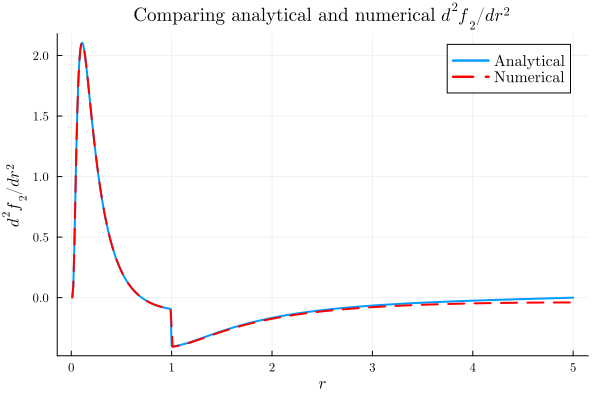

In [102]:
include("VMC_code.jl")
using Bessels

r = LinRange(0.01, 5.0, 500)  # Radial distances for g(r) calculation
R_match = 1.0 # Matching radius to validate continuity of f2
L = 10.0

# Test the continuity of f2 at the matching radius R_match

# First calculate the constants
constants = calculate_constants(L, R_match)
C1, C2, C3 = constants


f2 = Vector{Float64}(undef, length(r))
d2f2_dr2 = Vector{Float64}(undef, length(r))
d2f2_dr2_num = Vector{Float64}(undef, length(r))

for i in 1:length(r)
    f2[i] = exp(u2(r[i], R_match, L, constants))
    d2f2_dr2[i] = f2[i] * (u2_second_derivative(r[i], R_match, L, constants) + (u2_first_derivative(r[i], R_match, L, constants))^2)
    f2_plus = exp(u2(r[i] + 1e-5, R_match, L, constants))
    f2_minus = exp(u2(r[i] - 1e-5, R_match, L, constants))
    d2f2_dr2_num[i] = (f2_plus - 2 * f2[i] + f2_minus) / (1e-5)^2
end


using LaTeXStrings
using Plots
gr()
default(fontfamily="Computer Modern", titlefont=12, legendfont=10)

plot(r, d2f2_dr2, 
     label="Analytical", 
     xlabel=L"r", 
     ylabel=L"$d^2 f_2/dr^2$", 
     title=L"Comparing analytical and numerical $d^2f_2/dr^2$",
     linewidth=2)

plot!(r, d2f2_dr2_num, 
     label="Numerical", 
     xlabel=L"r", 
     ylabel=L"$d^2 f_2/dr^2$", 
     linewidth=2,
     color=:red,
     linestyle=:dash)
    

## Kinetic energy for 2-particles. Analytical vs. Numerical

Distance between particles: 4.942828225037338
Local Kinetic Energy: 0.039354104808766575
Numerical Local Kinetic Energy: 0.03951029098667456


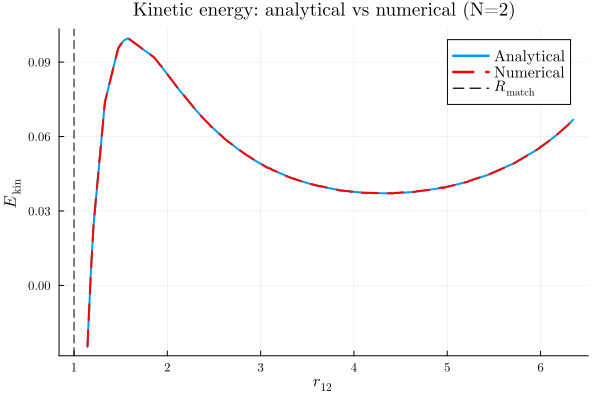

In [140]:
include("VMC_code.jl")

L = 10.0
R_match = 1.0
num_part = 2

kin_analytical = zeros(100)
kin_numerical = zeros(100)
r = zeros(100)

for i in 1:100
    x_coord =  L .* rand(num_part) .- L/2 
    y_coord =  L .* rand(num_part) .- L/2 

    dx = get_periodic_difference(x_coord[1], x_coord[2], L)
    dy = get_periodic_difference(y_coord[1], y_coord[2], L)
    dist = sqrt(dx^2 + dy^2)

    r[i] = dist

    positions = [x_coord'; y_coord']
    constants = calculate_constants(L, R_match)

    f2_plus  = exp(u2(dist + 1e-6, R_match, L, constants))
    f2_minus = exp(u2(dist - 1e-6, R_match, L, constants))
    f2_val   = exp(u2(dist, R_match, L, constants))

    d2f2_dr2 = (f2_plus - 2*f2_val + f2_minus) / (1e-6)^2
    df2_dr   = (f2_plus - f2_minus) / (2e-6)

    # Full 2D Laplacian for one particle, factor 2 for both particles
    local_kinetic_energy_numerical = -0.5 * 2 * (d2f2_dr2/f2_val + (1/dist) * df2_dr/f2_val)

    kin_analytical[i] = local_kinetic_energy(positions, L, R_match, constants)
    kin_numerical[i] = local_kinetic_energy_numerical
end

println("Distance between particles: ", dist)
println("Local Kinetic Energy: ", local_kinetic_energy(positions, L, R_match, constants))
println("Numerical Local Kinetic Energy: ", local_kinetic_energy_numerical)
using Plots


# Sort by r for cleaner plot
idx = sortperm(r)
p1 = plot(r[idx], kin_analytical[idx], 
     label="Analytical", linewidth=2,
     xlabel=L"r_{12}", ylabel=L"E_\mathrm{kin}",
     title="Kinetic energy: analytical vs numerical (N=2)")
     
plot!(r[idx], kin_numerical[idx], 
     label="Numerical", linestyle=:dash, linewidth=2, color=:red)
vline!([R_match], label=L"R_\mathrm{match}", linestyle=:dash, color=:black)
display(p1)



## Interaction potential for two particles

In [138]:
include("VMC_code.jl")
L = 10.0

# Test 1: known distance
x_coord = [0.0, 1.0]
y_coord = [0.0, 0.0]
positions = [x_coord'; y_coord']
# r = 1.0, so E_pot should be exactly 1.0/1.0^3 = 1.0
println("Test 1 - r=1.0")
println("Expected:   ", 1.0)
println("Analytical: ", local_interaction_energy(positions, L))

# Test 2: diagonal distance
x_coord = [0.0, 1.0]
y_coord = [0.0, 1.0]
positions = [x_coord'; y_coord']
# r = sqrt(2), so E_pot should be 1/sqrt(2)^3 = 1/(2sqrt(2))
println("\nTest 2 - r=sqrt(2)")
println("Expected:   ", 1.0/(2*sqrt(2)))
println("Analytical: ", local_interaction_energy(positions, L))

# Test 3: PBC — particle near boundary
x_coord = [-4.9, 4.9]
y_coord = [0.0, 0.0]
positions = [x_coord'; y_coord']
# minimum image distance = 0.2, so E_pot = 1/0.2^3 = 125.0
println("\nTest 3 - PBC, r=0.2 across boundary")
println("Expected:   ", 1.0/0.2^3)
println("Analytical: ", local_interaction_energy(positions, L))

Test 1 - r=1.0
Expected:   1.0
Analytical: 1.0

Test 2 - r=sqrt(2)
Expected:   0.35355339059327373
Analytical: 0.3535533905932738

Test 3 - PBC, r=0.2 across boundary
Expected:   124.99999999999997
Analytical: 125.00000000000134
